In [14]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

import shap

sns.set(style="whitegrid")
pd.set_option('display.max_columns', None)

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Portfolio/Water Quality/Combined_dataset.csv")

print("Dataset shape:", df.shape)
df.head()

In [ ]:
df.info()
df.isna().sum()

In [ ]:
#impute numeric and categorical variables separately
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

In [ ]:
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy="median")
df[num_cols] = num_imputer.fit_transform(df[num_cols])

In [ ]:
df[cat_cols] = df[cat_cols].fillna("Unknown")

In [ ]:
#target
y = df['CCME_Values']

#drop leakage + targets
X = df.drop(columns=[
    'CCME_Values',
    'CCME_WQI',
    'Date'
])

#identify column types
num_cols = X.select_dtypes(include=['int64','float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

print("Numeric:", list(num_cols))
print("Categorical:", list(cat_cols))

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, num_cols),
    ('cat', categorical_pipeline, cat_cols)
])

In [13]:
from sklearn.ensemble import RandomForestRegressor

baseline_model = RandomForestRegressor(
    n_estimators=150,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', baseline_model)
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Ammonia (mg/l)', 'Biochemical Oxygen Demand (mg/l)',
       'Dissolved Oxygen (mg/l)', 'Orthophosphate (mg/l)', 'pH (ph units)',
       'Temperature (cel)', 'Nitrogen (mg/l)', 'Nitrate (mg/l)'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Country', 'Area', 'Waterbody Type'], dtype='object'))])),
                ('model',
                 RandomForestRegressor(max_depth=12, n_estimators=150,
                                       n_jobs=-1, random_state=42))])

RMSE: 0.209
R² Score: 0.998


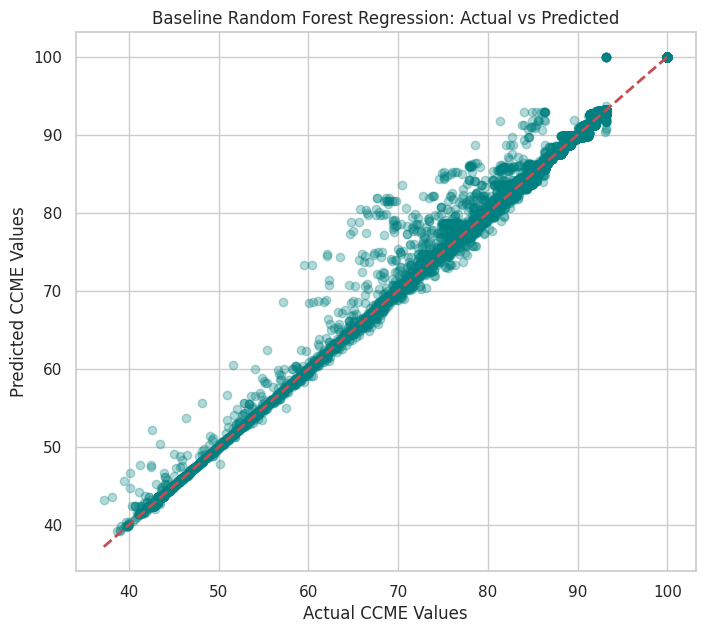

In [15]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

#predictions
y_pred = pipeline.predict(X_test)

#compute RMSE manually
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.3f}")
print(f"R² Score: {r2:.3f}")

#scatter plot: actual vs predicted
plt.figure(figsize=(8, 7))
plt.scatter(y_test, y_pred, alpha=0.3, color='teal')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2)
plt.xlabel("Actual CCME Values")
plt.ylabel("Predicted CCME Values")
plt.title("Baseline Random Forest Regression: Actual vs Predicted")
plt.show()

The baseline Random Forest model achieved an exceptionally high R² score. Because environmental data typically contains substantial noise, this result triggered a formal leakage audit. I conducted a correlation analysis across all numeric predictors to identify features that may have been directly or indirectly derived from the CCME Water Quality Index. This validation step ensured that model performance was not inflated by target leakage and reinforced the integrity of downstream regression and classification analyses.

In [16]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
numeric_df = df[num_cols]

In [17]:
corr_with_target = numeric_df.corr()['CCME_Values'].sort_values(ascending=False)
print(corr_with_target)

CCME_Values                         1.000000
pH (ph units)                       0.079743
Dissolved Oxygen (mg/l)            -0.029791
Temperature (cel)                  -0.109112
Nitrate (mg/l)                     -0.307599
Biochemical Oxygen Demand (mg/l)   -0.321557
Ammonia (mg/l)                     -0.392058
Nitrogen (mg/l)                    -0.610675
Orthophosphate (mg/l)              -0.659170
Name: CCME_Values, dtype: float64


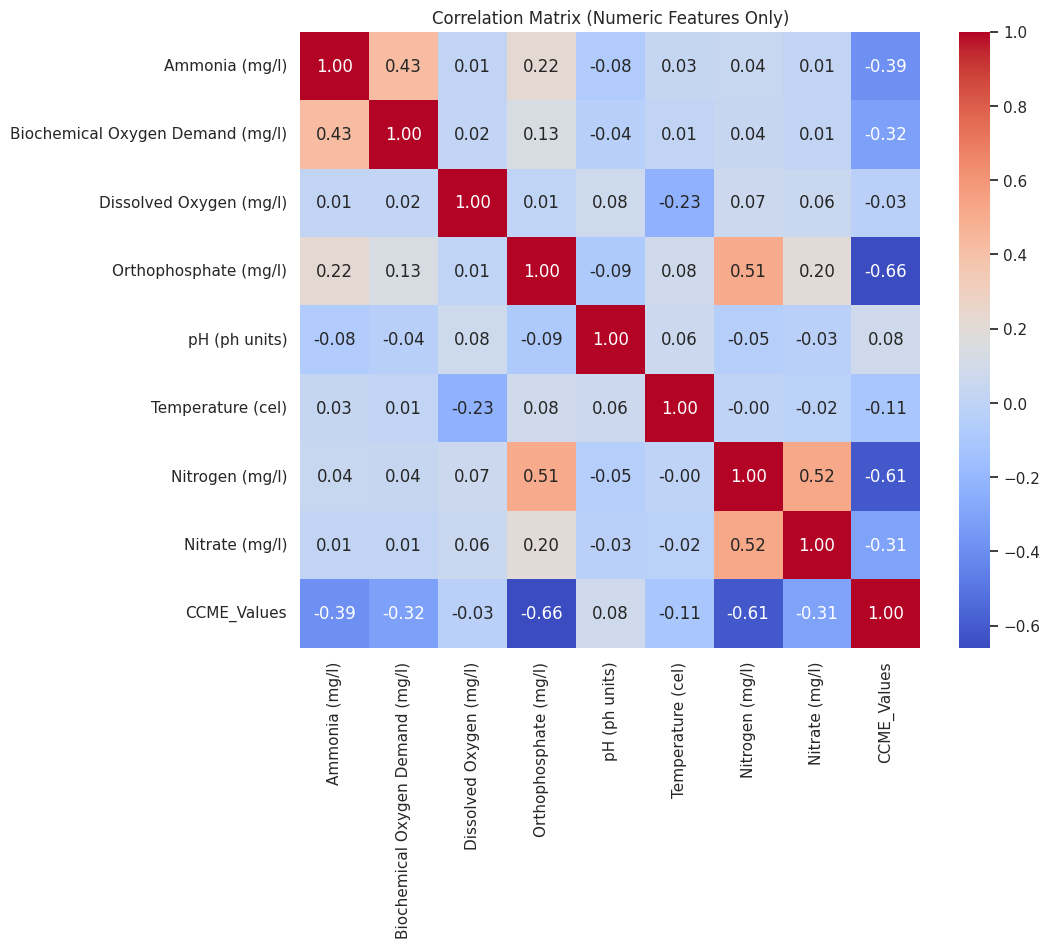

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix (Numeric Features Only)")
plt.show()

In [19]:
#leakage detection: correlation audit

import pandas as pd

#select numeric columns only
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
numeric_df = df[numeric_cols]

#compute correlations with target
corr_with_target = (
    numeric_df.corr()["CCME_Values"]
    .drop("CCME_Values")
    .sort_values(ascending=False)
)

#flag suspiciously high correlations
LEAKAGE_THRESHOLD = 0.95
potential_leakage = corr_with_target[abs(corr_with_target) > LEAKAGE_THRESHOLD]

print("Top correlations with CCME_Values:")
print(corr_with_target.head(10))

print("Potential leakage features (|corr| > 0.95):")
print(potential_leakage if not potential_leakage.empty else "None detected")

Top correlations with CCME_Values:
pH (ph units)                       0.079743
Dissolved Oxygen (mg/l)            -0.029791
Temperature (cel)                  -0.109112
Nitrate (mg/l)                     -0.307599
Biochemical Oxygen Demand (mg/l)   -0.321557
Ammonia (mg/l)                     -0.392058
Nitrogen (mg/l)                    -0.610675
Orthophosphate (mg/l)              -0.659170
Name: CCME_Values, dtype: float64
Potential leakage features (|corr| > 0.95):
None detected


The baseline Random Forest model achieved an exceptionally high R² score. Because environmental data typically contains substantial noise, this result triggered a formal leakage audit. I conducted a correlation analysis across all numeric predictors to identify features that may have been directly or indirectly derived from the CCME Water Quality Index. This validation step ensured that model performance was not inflated by target leakage and reinforced the integrity of downstream regression and classification analyses.

In [29]:
df['CCME_WQI'].value_counts(normalize=True)

,proportion
CCME_WQI,
Good,0.365529
Excellent,0.360933
Marginal,0.116244
Fair,0.112397
Poor,0.044897


In [30]:
#define classification features

clf_df = df.dropna(subset=['CCME_WQI']).copy()

X_clf = clf_df.drop(columns=[
    'CCME_WQI',
    'CCME_Values',
    'Date'
])

y_clf = clf_df['CCME_WQI']

In [31]:
from sklearn.model_selection import train_test_split

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf,
    y_clf,
    test_size=0.2,
    shuffle=False
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

clf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=16,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

clf_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', clf_model)
])

clf_pipeline.fit(X_train_c, y_train_c)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_c = clf_pipeline.predict(X_test_c)

print(classification_report(y_test_c, y_pred_c))

In [ ]:
cm = confusion_matrix(
    y_test_c,
    y_pred_c,
    labels=clf_pipeline.classes_
)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=clf_pipeline.classes_,
    yticklabels=clf_pipeline.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Water Quality Classification Confusion Matrix")
plt.show()

In [26]:
#binary risk classification

df_bin = df.dropna(subset=['CCME_WQI']).copy()

df_bin['risk_level'] = df_bin['CCME_WQI'].apply(
    lambda x: 'At Risk' if x in ['Fair', 'Marginal', 'Poor'] else 'Safe'
)

df_bin['risk_level'].value_counts(normalize=True)

,proportion
risk_level,
Safe,0.726462
At Risk,0.273538


In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

X_bin = df_bin.drop(columns=['risk_level', 'CCME_WQI', 'CCME_Values', 'Date'])
y_bin = df_bin['risk_level']

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_bin, y_bin, test_size=0.2, shuffle=False
)

bin_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=14,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

bin_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', bin_model)
])

bin_pipeline.fit(X_train_b, y_train_b)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Ammonia (mg/l)', 'Biochemical Oxygen Demand (mg/l)',
       'Dissolved Oxygen (mg/l)', 'Orthophosphate (mg/l)', 'pH (ph units)',
       'Temperature (cel)', 'Nitrogen (mg/l)', 'Nitrate (mg/l)'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Country', 'Area', 'Waterbody Type'], dtype='object'))])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=14,
                                        n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [28]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_b = bin_pipeline.predict(X_test_b)

print(classification_report(y_test_b, y_pred_b))

              precision    recall  f1-score   support

     At Risk       0.94      0.05      0.09      7068
        Safe       0.99      1.00      0.99    558528

    accuracy                           0.99    565596
   macro avg       0.96      0.52      0.54    565596
weighted avg       0.99      0.99      0.98    565596



The target variable was reformulated from a five-class CCME water quality index to a binary risk classification (“Safe” vs “At Risk”) to better reflect real-world environmental screening use cases. This adjustment reduced class imbalance (72.6% Safe / 27.3% At Risk) and significantly improved recall for potentially unsafe water conditions.